In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
csv_path = "archive/Data.csv"

df = pd.read_csv(csv_path, nrows=10000, low_memory=True)

print("Shape:", df.shape)
df.head()

Shape: (10000, 57)


,time,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,...,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11,label
0,2000-01-01 00:00:00,0.0,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,...,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447,0.0
1,2000-01-01 00:03:00,0.0,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,...,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194,0.0
2,2000-01-01 00:06:00,0.0,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,...,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530,0.0
3,2000-01-01 00:09:00,0.0,1.0,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,...,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089,0.0
4,2000-01-01 00:12:00,0.0,1.0,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,...,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461,0.0


In [3]:
print(df["label"].value_counts(dropna=False))

label
0.0    10000
Name: count, dtype: int64


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.select_dtypes(include=[np.number]).values)
print("Scaled shape:", X_scaled.shape)

Scaled shape: (10000, 56)


In [5]:
def create_sequences(data_array, seq_length=20):
    sequences = []
    for i in range(len(data_array) - seq_length + 1):
        sequences.append(data_array[i:i + seq_length])
    return np.array(sequences)

SEQ_LEN = 20
X_seq = create_sequences(X_scaled, SEQ_LEN)

print("Sequence shape:", X_seq.shape)

Sequence shape: (9981, 20, 56)


In [6]:
X_train, X_val = train_test_split(
    X_seq,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (7984, 20, 56)
X_val shape: (1997, 20, 56)


In [7]:
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, d_model):
        super().__init__()
        self.position_embeddings = layers.Embedding(
            input_dim=sequence_length, output_dim=d_model
        )
        self.sequence_length = sequence_length
        self.d_model = d_model

    def call(self, inputs):
        positions = tf.range(start=0, limit=self.sequence_length, delta=1)
        embedded_positions = self.position_embeddings(positions)
        return inputs + embedded_positions

In [8]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    x = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + inputs)

    ff = layers.Dense(ff_dim, activation="relu")(x)
    ff = layers.Dense(inputs.shape[-1])(ff)
    ff = layers.Dropout(dropout)(ff)

    return layers.LayerNormalization(epsilon=1e-6)(x + ff)

In [9]:
sequence_length = X_train.shape[1]
num_features = X_train.shape[2]

inputs = layers.Input(shape=(sequence_length, num_features))

# Project input to model dimension
x = layers.Dense(64)(inputs)

# Add positional information
x = PositionalEmbedding(sequence_length, 64)(x)

# Transformer encoder layers
x = transformer_encoder(x, head_size=32, num_heads=2, ff_dim=64, dropout=0.1)
x = transformer_encoder(x, head_size=32, num_heads=2, ff_dim=64, dropout=0.1)

# Decoder / reconstruction
x = layers.Dense(64, activation="relu")(x)
outputs = layers.TimeDistributed(layers.Dense(num_features))(x)

model = Model(inputs, outputs)
model.compile(optimizer="adam", loss="mse")

model.summary()



Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 20, 56)]             0         []                            
                                                                                                  
 dense (Dense)               (None, 20, 64)               3648      ['input_1[0][0]']             
                                                                                                  
 positional_embedding (Posi  (None, 20, 64)               1280      ['dense[0][0]']               
 tionalEmbedding)                                                                                 
                                                                                                  
 multi_head_attention (Mult  (None, 20, 64)               16640     ['positional_embedding[0

In [10]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30

63/63 [==============================] - 16s 111ms/step - loss: 0.7928 - val_loss: 0.5189
Epoch 2/30
63/63 [==============================] - 6s 87ms/step - loss: 0.3975 - val_loss: 0.2493
Epoch 3/30
63/63 [==============================] - 5s 83ms/step - loss: 0.2088 - val_loss: 0.1274
Epoch 4/30
63/63 [==============================] - 5s 86ms/step - loss: 0.1134 - val_loss: 0.0644
Epoch 5/30
63/63 [==============================] - 5s 81ms/step - loss: 0.0636 - val_loss: 0.0347
Epoch 6/30
63/63 [==============================] - 5s 80ms/step - loss: 0.0386 - val_loss: 0.0213
Epoch 7/30
63/63 [==============================] - 5s 82ms/step - loss: 0.0256 - val_loss: 0.0144
Epoch 8/30
63/63 [==============================] - 5s 81ms/step - loss: 0.0185 - val_loss: 0.0112
Epoch 9/30
63/63 [==============================] - 5s 81ms/step - loss: 0.0139 - val_loss: 0.0082
Epoch 10/30
63/63 [==============================] - 5s 80ms/step - loss: 0.0107 - val_loss: 0.0062
Epoch 

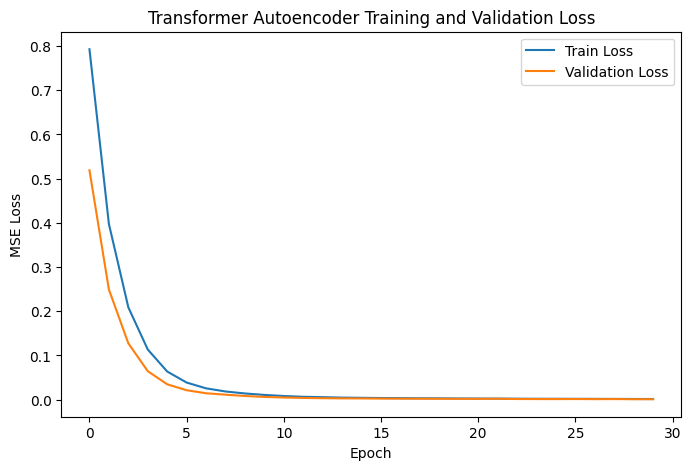

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Transformer Autoencoder Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [12]:
X_val_pred = model.predict(X_val)

val_mse = np.mean(np.power(X_val - X_val_pred, 2), axis=(1, 2))

print("Mean Reconstruction Error:", val_mse.mean())
print("Standard Deviation:", val_mse.std())
print("Maximum Reconstruction Error:", val_mse.max())

63/63 [==============================] - 2s 16ms/step
Mean Reconstruction Error: 0.0009185440727165936
Standard Deviation: 0.00018587322230475623
Maximum Reconstruction Error: 0.002197121384877757


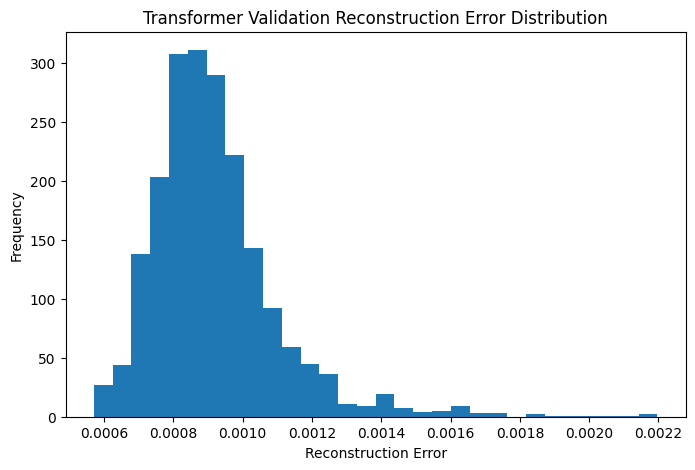

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(val_mse, bins=30)
plt.title("Transformer Validation Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.show()

In [14]:
threshold = val_mse.mean() + 3 * val_mse.std()
print("Anomaly Threshold:", threshold)

Anomaly Threshold: 0.0014761637396308622


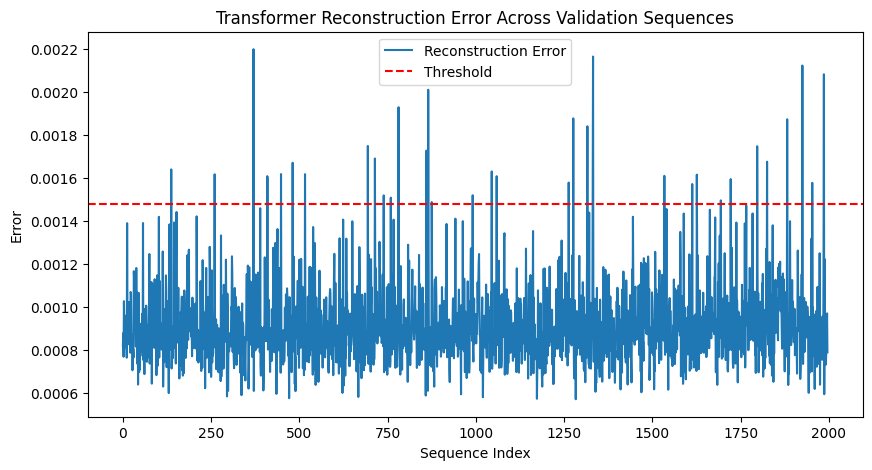

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(val_mse, label="Reconstruction Error")
plt.axhline(threshold, color="red", linestyle="--", label="Threshold")
plt.title("Transformer Reconstruction Error Across Validation Sequences")
plt.xlabel("Sequence Index")
plt.ylabel("Error")
plt.legend()
plt.show()

In [16]:
anomaly_flags = val_mse > threshold

print("Potential anomalies found:", anomaly_flags.sum())
print("Total validation sequences:", len(anomaly_flags))
print("Percentage flagged:", (anomaly_flags.sum() / len(anomaly_flags)) * 100, "%")

Potential anomalies found: 34
Total validation sequences: 1997
Percentage flagged: 1.7025538307461192 %


In [17]:
model.save("train3_transformer_autoencoder.keras")
joblib.dump(scaler, "train3_transformer_scaler.pkl")

print("Transformer model and scaler saved successfully.")

Transformer model and scaler saved successfully.


In [18]:
results_df = pd.DataFrame({
    "sequence_index": np.arange(len(val_mse)),
    "reconstruction_error": val_mse,
    "is_above_threshold": anomaly_flags
})

results_df.to_csv("train3_transformer_results.csv", index=False)

print("Results saved to train3_transformer_results.csv")
results_df.head()

Results saved to train3_transformer_results.csv


,sequence_index,reconstruction_error,is_above_threshold
0,0,0.000818,False
1,1,0.000877,False
2,2,0.000768,False
3,3,0.001026,False
4,4,0.000877,False


In [21]:
mean_error = val_mse.mean()
anomalies = (val_mse > threshold).sum()
total = len(val_mse)
rate = anomalies / total * 100

mean_error, anomalies, total, rate

(0.0009185440727165936, 34, 1997, 1.7025538307461192)